<h1 style="text-align:center; color:green; font-size:48px;">
STEP 2 - EXTENDED DH NETWORK
</h1>

#### Install libraries (if you did not do it before on the terminal)

In [1]:
#!pip install numpy==2.0.2 pandas==2.3.1
#!pip install matplotlib
#!pip install git+https://github.com/oemof/dhnx.git@dev
#!pip install osmnx==1.9.4 oemof.solph==0.5.6

# Import libraries

In [2]:
import matplotlib.pyplot as plt
import dhnx
import pandas as pd
import oemof.solph
from pyomo.environ import SolverFactory

Need to install CoolProp to use the hydraulic pre-calculation module.


# Example 1 

## 1.1 Create network and plot

In [3]:
# Initialize thermal network
network = dhnx.network.ThermalNetwork()

# Load town parameter
network = network.from_csv_folder(r"Input_data/twn_data")

# Load investment parameter
invest_opt = dhnx.input_output.load_invest_options(r"Input_data/invest_data")

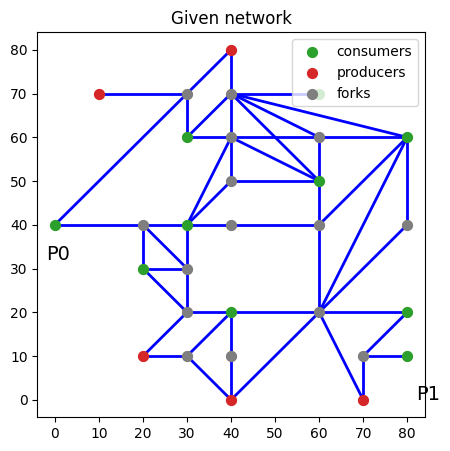

In [4]:
# plot initial/given network
static_map = dhnx.plotting.StaticMap(network) # That's how DHNx plots the network
static_map.draw(background_map=False) # This line to show the network on a blank area.
plt.title('Given network') 

#Scatter plots to differentiate the consumers, producers and forks. 
plt.scatter(network.components.consumers['lon'], network.components.consumers['lat'],
            color='tab:green', label='consumers', zorder=2.5, s=50) 
plt.scatter(network.components.producers['lon'], network.components.producers['lat'],
            color='tab:red', label='producers', zorder=2.5, s=50)
plt.scatter(network.components.forks['lon'], network.components.forks['lat'],
            color='tab:grey', label='forks', zorder=2.5, s=50)
plt.text(-2, 32, 'P0', fontsize=14)
plt.text(82, 0, 'P1', fontsize=14)
plt.legend()
plt.show()

## 1.2 Investment optimization of the network

In [5]:
# Optimize the investment data
network.optimize_investment(invest_options=invest_opt,  solver='cbc')


c:\Users\Yanayra\anaconda3\envs\env_P2\lib\site-packages\oemof\solph\flows\_flow.py:163: FutureWarning: For backward compatibility, the option investment overwrites the option nominal_value. Both options cannot be set at the same time.
  warn(msg, FutureWarning)
c:\Users\Yanayra\anaconda3\envs\env_P2\lib\site-packages\oemof\network\network\nodes.py:250: FutureWarning: Usage of oemof.network.Component is deprecated. Use oemof.network.Node instead.
  warnings.warn(


Welcome to the CBC MILP Solver 
Version: 2.10.12 
Build Date: Aug  2 2025 

command line - C:\Users\Yanayra\anaconda3\envs\env_P2\Library\bin\cbc.exe -printingOptions all -import C:\Users\Yanayra\AppData\Local\Temp\tmp7eujhk62.pyomo.lp -stat=1 -solve -solu C:\Users\Yanayra\AppData\Local\Temp\tmp7eujhk62.pyomo.soln (default strategy 1)
Option for printingOptions changed from normal to all
Presolve 979 (-1706) rows, 954 (-1411) columns and 3164 (-3036) elements
Statistics for presolved model
Original problem has 295 integers (295 of which binary)
Presolved problem has 295 integers (295 of which binary)
==== 364 zero objective 81 different
==== absolute objective values 81 different
==== for integers 0 zero objective 40 different
==== for integers absolute objective values 40 different
===== end objective counts


Problem has 979 rows, 954 columns (590 with objective) and 3164 elements
Column breakdown:
659 of type 0.0->inf, 0 of type 0.0->up, 0 of type lo->inf, 
0 of type lo->up, 0 of ty

INFO:root:Optimization successful...


## 1.3 Results postprocessing and Plotting 


      from_node      to_node hp_type     capacity  direction          costs  \
id                                                                            
0   producers-1      forks-9    None     0.000000          0       0.000000   
1   producers-1     forks-10   DN100  2690.587100          1  243795.556108   
2   producers-2      forks-9    None     0.000000          0       0.000000   
3       forks-9  consumers-0    None     0.000000          0       0.000000   
4       forks-9  consumers-2    None     0.000000          0       0.000000   
5      forks-10  consumers-2    DN80   532.834390          1  315531.337190   
6      forks-10      forks-5    None     0.000000          0       0.000000   
7      forks-10  consumers-3    None     0.000000          0       0.000000   
8      forks-10     forks-11    DN80  1095.033600          1  499050.643735   
9      forks-10  consumers-6    None     0.000000          0       0.000000   
10     forks-10  consumers-5    DN80  1062.049100   

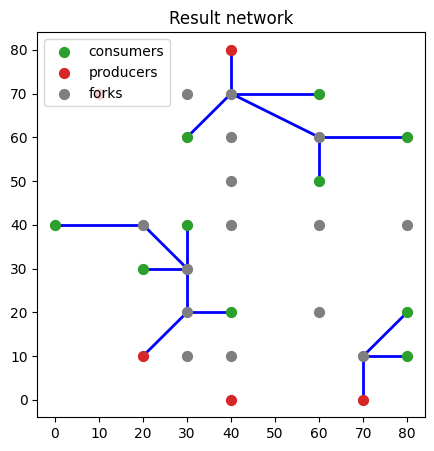

In [6]:
# ####### Postprocessing and Plotting ###########
results_edges = network.results.optimization['components']['pipes']
print(results_edges[['from_node', 'to_node', 'hp_type', 'capacity',
                     'direction', 'costs', 'losses']])

import os

# Create the folder if it does not exist
os.makedirs("Outputs", exist_ok=True)

# Now save the results
results_edges.to_csv("Outputs/Ex1.results_edges.csv", index=True)


print('Objective value: ', network.results.optimization['oemof_meta']['objective'])

# assign new ThermalNetwork with invested pipes
twn_results = network
twn_results.components['pipes'] = results_edges[results_edges['capacity'] > 0.001]

# plot invested edges
static_map_2 = dhnx.plotting.StaticMap(twn_results)
static_map_2.draw(background_map=False)
plt.title('Result network')
plt.scatter(network.components.consumers['lon'], network.components.consumers['lat'],
            color='tab:green', label='consumers', zorder=2.5, s=50)
plt.scatter(network.components.producers['lon'], network.components.producers['lat'],
            color='tab:red', label='producers', zorder=2.5, s=50)
plt.scatter(network.components.forks['lon'], network.components.forks['lat'],
            color='tab:grey', label='forks', zorder=2.5, s=50)

plt.legend()
plt.show()

# Example 2